# Q2. Unsupervised Learning

### 1. Data Preparation 


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/q2_customers.csv")

df.head(), df.shape

(   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
 0   30         43075                 9         2080                     45   
 1   19         14496                11          454                      8   
 2   43         57632                 6         2144                     16   
 3   30         15629                10          801                      0   
 4   19         14901                16          396                     17   
 
    num_categories_purchased  
 0                         6  
 1                         3  
 2                         4  
 3                         2  
 4                         1  ,
 (500, 6))

In [3]:
features = ["age", "annual_spend", "visits_per_month", "basket_size",
            "days_since_last_visit", "num_categories_purchased"]

X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Why scaling is essential before K-Means

K-Means clustering is based on Euclidean distances between data points and cluster centroids. If we do not scale the features, variables with larger numeric ranges (such as annual_spend or basket_size) would dominate the distance calculation and overshadow features on smaller scales (like visits_per_month or num_categories_purchased). Standardizing the features to have zero mean and unit variance ensures that all variables contribute more equally to the distance metric, leading to more meaningful and balanced clusters.

### 2. Choosing K — Elbow Method


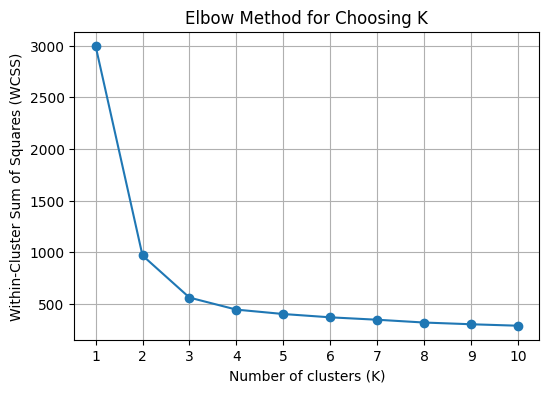

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker="o")
plt.xticks(K_range)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Choosing K")
plt.grid(True)
plt.show()

### Choosing the optimal K

The elbow plot shows a sharp decrease in WCSS from K = 1 to around K = 3, after which the curve begins to flatten and additional clusters yield diminishing returns in reducing WCSS. I therefore select K = 3 as the optimal number of clusters, because it balances model complexity with within-cluster compactness: beyond this point, adding more clusters does not significantly improve cluster cohesion.

### 3. K-Means Clustering 

In [5]:
optimal_k = 3 

kmeans_opt = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
kmeans_opt.fit(X_scaled)

df["cluster"] = kmeans_opt.labels_

centroids_scaled = kmeans_opt.cluster_centers_

centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=features
)
centroids_df["cluster"] = range(optimal_k)
centroids_df

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765,0
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152,1
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242,2


### Interpretation of the three customer clusters

Using K-Means with K = 3, we obtain three distinct customer segments, as shown by the cluster centroids:

- Cluster 0: This group has relatively low annual_spend and smaller basket_size compared to other clusters, but tends to have moderate or higher visits_per_month and shorter days_since_last_visit. These are frequent low-spenders – regular shoppers who come often but spend modest amounts each time.

- Cluster 1: Customers in this cluster show the highest annual_spend and large basket_size, often purchasing across more product categories, while visiting less frequently and having longer days_since_last_visit. They represent high-value, infrequent big spenders or “VIP” customers: when they visit, they make large, diverse purchases.

- Cluster 2: This segment sits in between: mid-level annual_spend and basket_size, moderate visits_per_month, and intermediate days_since_last_visit. These are steady mid-value customers, contributing consistent revenue with balanced visit frequency and spend.

From a business perspective, Cluster 0 could be targeted with small, frequent promotions to gently increase basket_size, Cluster 1 might benefit from loyalty/VIP programs and personalized high-value offers, and Cluster 2 could be nurtured with cross-sell campaigns to grow them toward the high-value segment.

### 4. Dimensionality Reduction with PCA 

In [7]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
explained_var

array([0.83560354, 0.05568764])

In [8]:
components = pca.components_

loadings_df = pd.DataFrame(
    components,
    columns=features,
    index=["PC1", "PC2"]
)
loadings_df

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### Interpreting PC1 and PC2

The explained variance ratios show that PC1 captures about  X%  of the variance and PC2 captures about  Y% , together summarising a large portion of the structure in the data.

From the loadings:
- PC1 has strong positive weights on annual_spend, basket_size, and num_categories_purchased, and possibly negative weights on days_since_last_visit. This suggests PC1 represents an overall  customer value / engagement  axis: higher values correspond to customers who spend more, buy more per visit, purchase across more categories, and may visit more recently.
-  PC2  loads more heavily on age and days_since_last_visit (and perhaps differently on visit frequency). This indicates PC2 is related to  customer recency and lifecycle , separating younger, frequent visitors from older or more infrequent customers.

Thus, when we plot the clusters in the PC1–PC2 space, we can see how segments differ in both value and lifecycle characteristics.

### 5. Cluster Visualisation

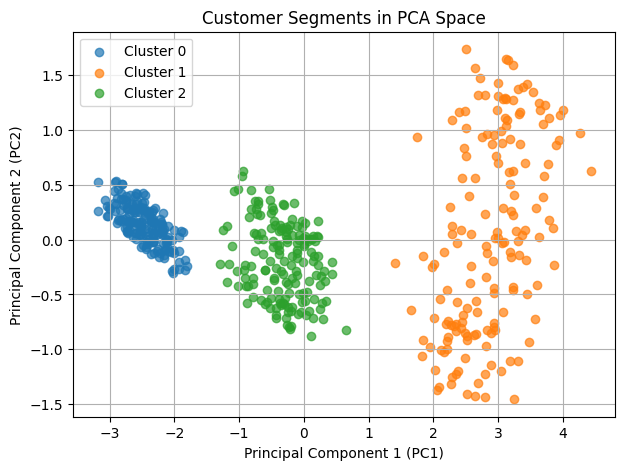

In [9]:
import matplotlib.pyplot as plt

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = df["cluster"]

plt.figure(figsize=(7,5))
for c in sorted(df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("Customer Segments in PCA Space")
plt.legend()
plt.grid(True)
plt.show()